# Customer Churn Analysis

## Project Information

**Project Type:** Customer Churn Analysis

**Dataset:** Telco Customer Churn Dataset

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

**Dataset Size:** 7,032 customers and 21 features

**Objective:** Analyze customer data to identify patterns and factors associated with customer churn.

**Analysis Performed:**
- Data cleaning and preprocessing
- Churn distribution analysis
- Customer demographic analysis
- Contract and payment method analysis
- Internet service and support service analysis
- Tenure and charges analysis
- Correlation analysis
- Data visualization

**Key Metrics:**
- Total customers: 7,032
- Churned customers: 1,869
- Overall churn rate: 26.58%
- Average tenure of retained customers: 37.65 months
- Average tenure of churned customers: 17.98 months
- Average monthly charges of retained customers: 61.31
- Average monthly charges of churned customers: 74.44

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
19.65     8
45.3      7
19.55     7
20.15     6
20.25     6
Name: count, dtype: int64

In [21]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [23]:
df["TotalCharges"].isnull().sum()

11

In [25]:
df = df.dropna(subset=["TotalCharges"])

In [27]:
df.shape

(7032, 21)

In [29]:
df.duplicated().sum()

0

In [31]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [33]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
churn_rate

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

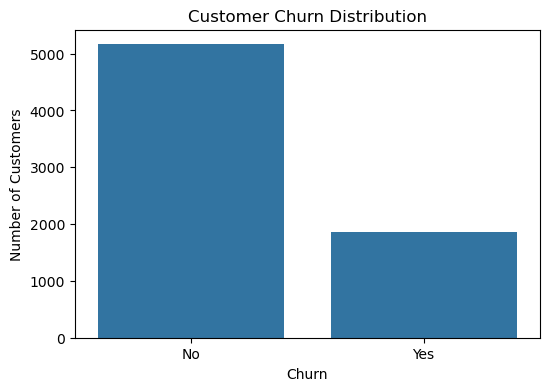

In [35]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
gender_churn = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
gender_churn

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


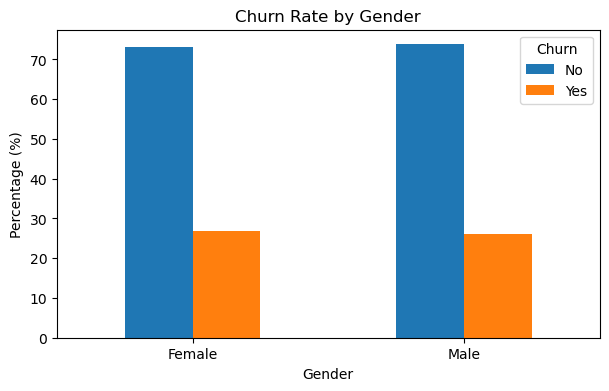

In [39]:
gender_churn.plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [45]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
 ) * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


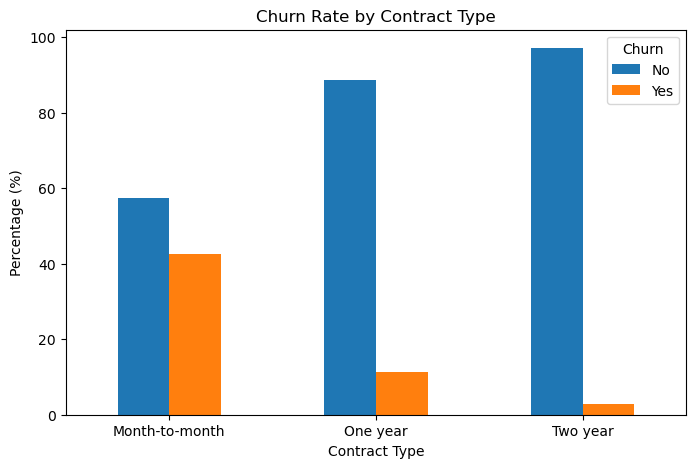

In [47]:
contract_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [49]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


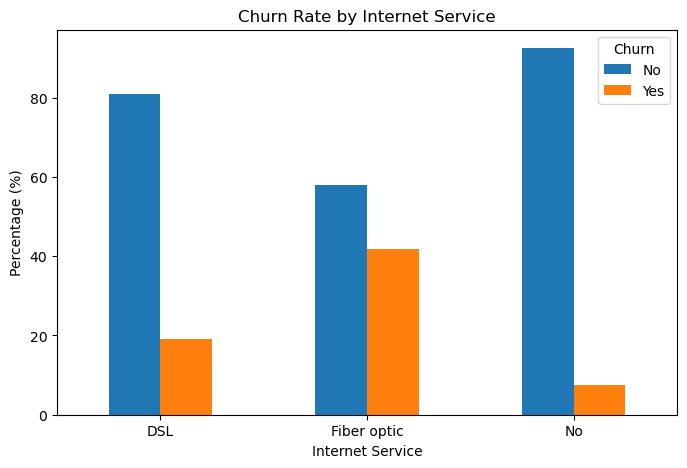

In [51]:
internet_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [53]:
tenure_churn = df.groupby("Churn")["tenure"].describe()
tenure_churn

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [55]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

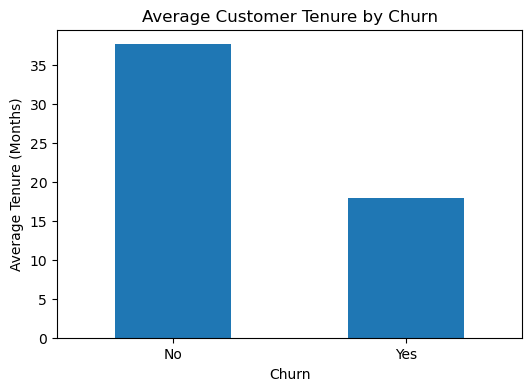

In [57]:
avg_tenure = df.groupby("Churn")["tenure"].mean()

avg_tenure.plot(kind="bar", figsize=(6, 4))

plt.title("Average Customer Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.show()


In [59]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

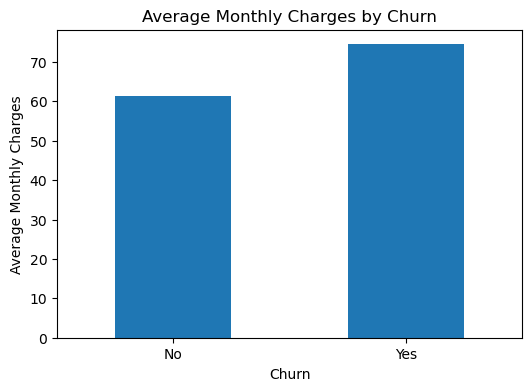

In [61]:
avg_monthly_charges = df.groupby("Churn")["MonthlyCharges"].mean()

avg_monthly_charges.plot(kind="bar", figsize=(6, 4))

plt.title("Average Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.show()

In [63]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


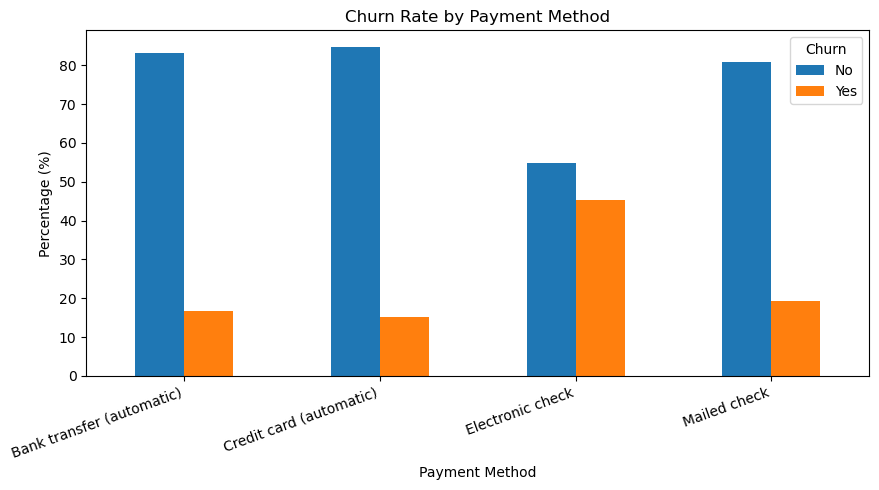

In [65]:
payment_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [67]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


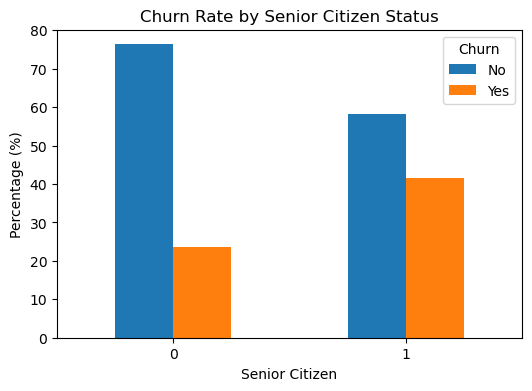

In [69]:
senior_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [71]:
techsupport_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


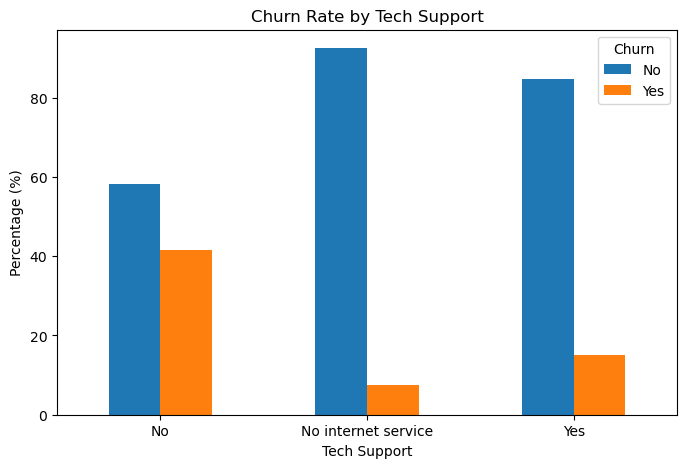

In [73]:
techsupport_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [75]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


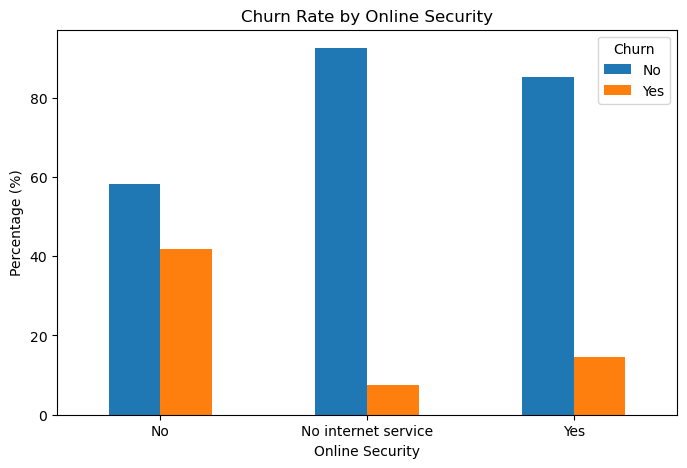

In [77]:
security_churn.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [79]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

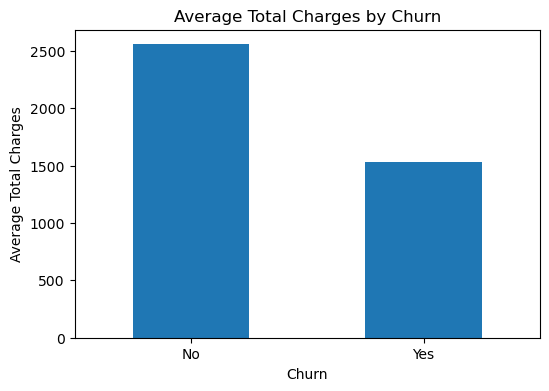

In [81]:
avg_total_charges = df.groupby("Churn")["TotalCharges"].mean()

avg_total_charges.plot(kind="bar", figsize=(6, 4))

plt.title("Average Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Total Charges")
plt.xticks(rotation=0)
plt.show()

In [83]:
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols].corr()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


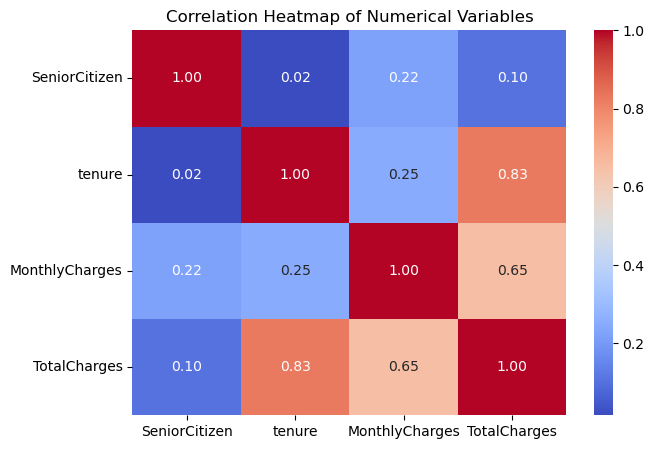

In [85]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [87]:
contract_payment_churn = pd.crosstab(
    [df["Contract"], df["PaymentMethod"]],
    df["Churn"],
    normalize="index"
) * 100

contract_payment_churn

Churn                                            No        Yes
Contract       PaymentMethod                                  
Month-to-month Bank transfer (automatic)  65.874363  34.125637
               Credit card (automatic)    67.219153  32.780847
               Electronic check           46.270270  53.729730
               Mailed check               68.421053  31.578947
One year       Bank transfer (automatic)  90.281330   9.718670
               Credit card (automatic)    89.698492  10.301508
               Electronic check           81.556196  18.443804
               Mailed check               93.154762   6.845238
Two year       Bank transfer (automatic)  96.619217   3.380783
               Credit card (automatic)    97.758621   2.241379
               Electronic check           92.261905   7.738095
               Mailed check               99.200000   0.800000

In [89]:
print("Total Customers:", len(df))
print("Churned Customers:", (df["Churn"] == "Yes").sum())
print("Overall Churn Rate:", round((df["Churn"] == "Yes").mean() * 100, 2), "%")
print("Average Tenure - Stayed:", round(df[df["Churn"] == "No"]["tenure"].mean(), 2), "months")
print("Average Tenure - Churned:", round(df[df["Churn"] == "Yes"]["tenure"].mean(), 2), "months")
print("Average Monthly Charges - Stayed:", round(df[df["Churn"] == "No"]["MonthlyCharges"].mean(), 2))
print("Average Monthly Charges - Churned:", round(df[df["Churn"] == "Yes"]["MonthlyCharges"].mean(), 2))

Total Customers: 7032
Churned Customers: 1869
Overall Churn Rate: 26.58 %
Average Tenure - Stayed: 37.65 months
Average Tenure - Churned: 17.98 months
Average Monthly Charges - Stayed: 61.31
Average Monthly Charges - Churned: 74.44


## Key Findings

- The overall customer churn rate is **26.58%**.
- Customers who churned had a lower average tenure (**17.98 months**) compared with customers who stayed (**37.65 months**).
- Customers who churned had higher average monthly charges (**74.44**) compared with customers who stayed (**61.31**).
- Month-to-month contracts showed higher churn rates than longer-term contracts in this dataset.
- Fiber optic customers had a higher observed churn rate than DSL and customers without internet service.
- Customers using electronic checks had a higher observed churn rate than other payment methods.
- Customers without Tech Support or Online Security had higher observed churn rates than customers who had these services.
- The correlation analysis showed a strong positive relationship between **tenure and TotalCharges**.

## Conclusion

The Customer Churn Analysis provided useful insights into customer behavior and the factors associated with churn. The analysis showed that churn was related to differences in contract type, internet service, payment method, support services, tenure, and monthly charges.

Customers who churned had a lower average tenure and higher average monthly charges compared with customers who stayed. The analysis also showed a strong relationship between tenure and TotalCharges.

Overall, this project helped demonstrate how Python, Pandas, Matplotlib, and Seaborn can be used to clean customer data, explore patterns, create visualizations, and generate meaningful business insights.